# NBA Predictive Analytics Project (2024-25 Season)

### Ashley Mann | August 2026

Data: https://www.kaggle.com/datasets/eduardopalmieri/nba-player-stats-season-2425

***

## Background & Context

For this project, we'll be using the 2024-2025 NBA Player Stats dataset from Kaggle (link above). The dataset contains 28,254 game-level observations across all NBA teams, with variables describing player performance, playing time, and game context.

The goal is to understand and quantify the relationship between minutes played and points scored. While many variables in the dataset could theoretically be predicted, the focus here is on the fundamental relationship: given a player's minutes on the court, how many points will they score? This EDA establishes that foundational relationship before moving to formal regression analysis and diagnostics.

### Research Question

Given the number of minutes an athlete plays, how many points will they score?

### Data

28,254 game-level player observations from Kaggle's 2024-25 NBA season dataset.

### Model

Simple linear regression: PTS ~ MinPlay (predict total points scored from minutes played).

### Data Dictionary / Column Descriptions

| Column | Description |
|--------|-------------|
| Player | Name of the player. |
| Tm | Abbreviation of the player's team. |
| Opp | Abbreviation of the opposing team. |
| Result | Result of the game for the player's team. |
| MP | Minutes played, represented as a float (e.g., `23.5` = 23 minutes and 30 seconds). |
| FG | Field goals made. |
| FGA | Field goal attempts. |
| FG% | Field goal percentage. |
| 3P | 3-point field goals made. |
| 3PA | 3-point field goal attempts. |
| 3P% | 3-point shooting percentage. |
| FT | Free throws made. |
| FTA | Free throw attempts. |
| FT% | Free throw percentage. |
| ORB | Offensive rebounds. |
| DRB | Defensive rebounds. |
| TRB | Total rebounds. |
| AST | Assists. |
| STL | Steals. |
| BLK | Blocks. |
| TOV | Turnovers. |
| PF | Personal fouls. |
| PTS | Total points scored. |
| +/- | Plus/minus, the point differential when the player is on court. |
| GmSc | Game Score, a metric summarizing player performance for the game. |
| Date | Date of the game in `YYYY-MM-DD` format. |

***

## Project Outline

#### 1. Exploratory Data Analysis (EDA)
- Examine data structure and shape
- Check for missing values and data types
- Visualize distributions of key variables (PTS, MP)
- Look for outliers and anomalies
- Basic summary statistics

#### 2. Data Preparation
- Handle missing values
- Remove or flag problematic rows
- Ensure variables are in correct format for modeling

#### 3. Linear Regression: Points from Minutes Played
- Fit OLS model: `PTS ~ MP`
- Extract and interpret coefficients
- Examine model summary (R-squared, F-statistic, p-values)

#### 4. Model Diagnostics & Assumptions
- Check normality of residuals (Jarque-Bera test, Q-Q plot)
- Examine residual plots
- Assess homoscedasticity
- Identify any violations of assumptions

#### 5. Inference & Interpretation
- Confidence intervals on coefficient estimates
- P-values and statistical significance
- Practical interpretation of results

#### 6. Predictions & Visualization
- Generate predictions across a range of MP values
- Calculate confidence intervals and prediction intervals
- Create visualization grid showing:
  - Actual data points (scatter)
  - Predicted line (regression line)
  - Confidence interval ribbon
  - Uncertainty bands

#### 7. Repeat for Additional Outcomes (Optional)
- Build separate models for: FG, 3P, FT, AST from MP
- Apply same workflow to each

#### 8. Summary & Conclusions
- Compare model results across all outcomes
- Discuss findings and patterns

***

## Hypothesis & Assumptions

#### Hypothesis
There is a positive linear relationship between minutes played and points scored. For every additional minute played, a player scores approximately X more points (to be estimated from the model).

#### Assumptions
- Linear relationship between MP and PTS
- Observations are independent
- Errors are normally distributed around the regression line
- Constant variance across all levels of minutes (homoscedasticity)

#### Limitations & Notes
- Linearity may not hold perfectly; residual plots will reveal any curvature or threshold effects
- Independence assumption is imperfect: the same players appear across multiple games, and injuries/performance streaks carry over between games. With a large sample siz
(n=28k), this violation is unlikely to severely bias results, but it warrants acknowledgment
- Relationship is simplified; individual player talent, role, and team context are captured in residuals, not modeled explicitly

***

<span style="color:#17A697">

## 0. Imports & Read in Data

</span>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot

In [8]:
df = pd.read_csv('/Users/AMann/Desktop/Coding/NBA Prediction/nba_dailyleaders_full_24_25.csv')
df.head()

,Player,Tm,Unnamed: 3,Opp,Result,MP,FG,FGA,FG%,3P,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
0,Jayson Tatum,BOS,NaN,NYK,W,30:18,14,18,0.778,8,...,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,Anthony Davis,LAL,NaN,MIN,W,37:35,11,23,0.478,1,...,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,Derrick White,BOS,NaN,NYK,W,26:38,8,13,0.615,6,...,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,Jrue Holiday,BOS,NaN,NYK,W,30:31,7,9,0.778,4,...,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,Miles McBride,NYK,@,BOS,L,25:51,8,10,0.800,4,...,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22


In [9]:
df.iloc[:10, :14]

,Player,Tm,Unnamed: 3,Opp,Result,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA
0,Jayson Tatum,BOS,NaN,NYK,W,30:18,14,18,0.778,8,11,0.727,1,2
1,Anthony Davis,LAL,NaN,MIN,W,37:35,11,23,0.478,1,3,0.333,13,15
2,Derrick White,BOS,NaN,NYK,W,26:38,8,13,0.615,6,10,0.600,2,2
3,Jrue Holiday,BOS,NaN,NYK,W,30:31,7,9,0.778,4,6,0.667,0,0
4,Miles McBride,NYK,@,BOS,L,25:51,8,10,0.800,4,5,0.800,2,3
5,Rui Hachimura,LAL,NaN,MIN,W,35:05,7,14,0.500,1,4,0.250,3,4
6,Jaylen Brown,BOS,NaN,NYK,W,29:54,7,18,0.389,5,9,0.556,4,4
7,Rudy Gobert,MIN,@,LAL,L,35:20,5,8,0.625,0,0,NaN,3,4
8,Julius Randle,MIN,@,LAL,L,34:19,5,10,0.500,1,3,0.333,5,7
9,Al Horford,BOS,NaN,NYK,W,26:05,4,7,0.571,3,5,0.600,0,0


In [10]:
df.iloc[:10, 13:]

,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
0,2,0.500,0,4,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,15,0.867,3,13,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,2,1.000,0,3,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,0,NaN,2,2,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,3,0.667,0,0,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22
5,4,0.750,3,2,5,1,2,1,0,2,18,19.0,15.9,2024-10-22
6,4,1.000,2,5,7,1,1,0,1,3,23,23.0,15.6,2024-10-22
7,4,0.750,3,11,14,2,0,1,1,4,13,-10.0,13.9,2024-10-22
8,7,0.714,3,6,9,4,0,0,2,3,16,2.0,13.7,2024-10-22
9,0,NaN,0,3,3,5,1,1,0,2,11,19.0,13.0,2024-10-22


***

<span style="color:#17A697">

## 1. Exploratory Data Analysis

- Examine data structure and shape
- Check for missing values and data types
- Visualize distributions of key variables (PTS, MP)
- Look for outliers and anomalies
- Basic summary statistics

</span>

<span style="color:#17A697">

#### 1A. Examine data structure and shape

- How many rows and columns are in each data set?
- What are the names and data types for each column?
- How many unique values are there for each column?

</span>

In [11]:
df.shape

(28265, 27)

In [12]:
df.nunique()

Player         569
Tm              30
Unnamed: 3       1
Opp             30
Result           2
MP            2700
FG              23
FGA             40
FG%            200
3P              12
3PA             21
3P%             74
FT              22
FTA             25
FT%             73
ORB             14
DRB             22
TRB             27
AST             23
STL              9
BLK             11
TOV             12
PF               7
PTS             60
+/-             98
GmSc           489
Date           214
dtype: int64

In [13]:
df.columns

Index(['Player', 'Tm', 'Unnamed: 3', 'Opp', 'Result', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', '+/-', 'GmSc', 'Date'],
      dtype='str')

<span style="color:#17A697">

#### 1B. Check for missing values and data types

</span>

In [14]:
df.isna().sum()

Player            0
Tm                0
Unnamed: 3    14208
Opp               0
Result            0
MP                0
FG                0
FGA               0
FG%            1643
3P                0
3PA               0
3P%            5817
FT                0
FTA               0
FT%           12900
ORB               0
DRB               0
TRB               0
AST               0
STL               0
BLK               0
TOV               0
PF                0
PTS               0
+/-              18
GmSc              0
Date              0
dtype: int64

In [15]:
df.dtypes

Player            str
Tm                str
Unnamed: 3        str
Opp               str
Result            str
MP                str
FG              int64
FGA             int64
FG%           float64
3P              int64
3PA             int64
3P%           float64
FT              int64
FTA             int64
FT%           float64
ORB             int64
DRB             int64
TRB             int64
AST             int64
STL             int64
BLK             int64
TOV             int64
PF              int64
PTS             int64
+/-           float64
GmSc          float64
Date              str
dtype: object

In [16]:
drop = df.drop(columns=['Unnamed: 3', '+/-'])
drop.head()

,Player,Tm,Opp,Result,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Date
0,Jayson Tatum,BOS,NYK,W,30:18,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37:35,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26:38,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30:31,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25:51,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22


<span style="color:#E2725B">

Dropping unnecessary columns.

</span>

In [17]:
new_df = drop.rename(columns = {'Tm': 'Team', 'MP': 'MinPlay', 'GmSc': 'GameScore', 'PTS': 'Points'})
new_df.columns

Index(['Player', 'Team', 'Opp', 'Result', 'MinPlay', 'FG', 'FGA', 'FG%', '3P',
       '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'Points', 'GameScore', 'Date'],
      dtype='str')

<span style="color:#E2725B">

Renaming columns based on preferences.

</span>

In [18]:
def time_to_float(time_string):
    if isinstance(time_string, float):
        return time_string
    minutes, seconds = time_string.split(':')
    decimal_minutes = float(minutes) + float(seconds) / 60
    return decimal_minutes

<span style="color:#E2725B">

Converting minutes from a string to a float.

</span>

In [19]:
new_df['MinPlay'] = new_df['MinPlay'].apply(time_to_float)

In [20]:
new_df['MinPlay'].head(10)

0    30.300000
1    37.583333
2    26.633333
3    30.516667
4    25.850000
5    35.083333
6    29.900000
7    35.333333
8    34.316667
9    26.083333
Name: MinPlay, dtype: float64

In [21]:
new_df['MinPlay'].isna().sum()

np.int64(0)

<span style="color:#E2725B">

Minutes converted to float dtype.

</span>

<span style="color:#17A697">

#### 1C. Visualize distributions of key variables

Focus on points and minutes played.

</span>

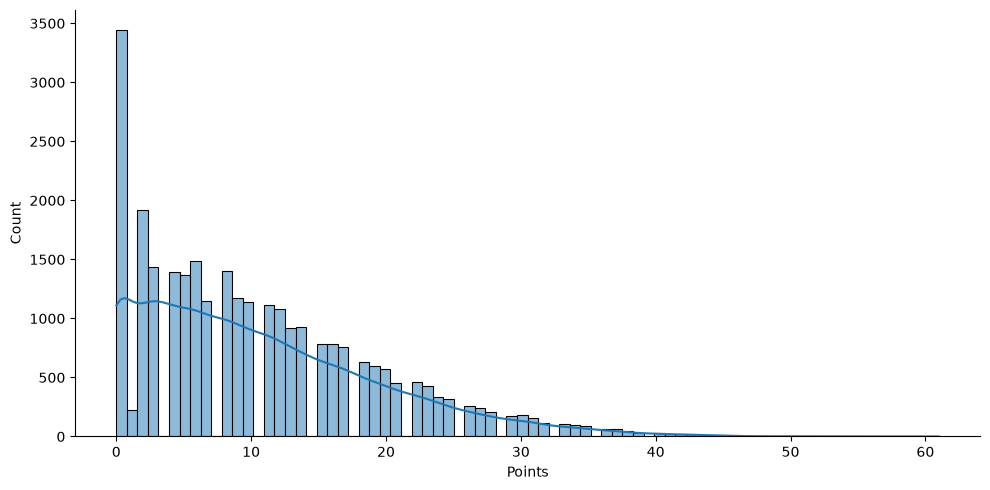

In [22]:
sns.displot(data = new_df, x = 'Points', kind = 'hist', kde = True, aspect = 2)
plt.show()

<span style="color:#E2725B">

Points are heavily skewed with most of the values concentrated around the lower end with fewer values on the upper end.

</span>

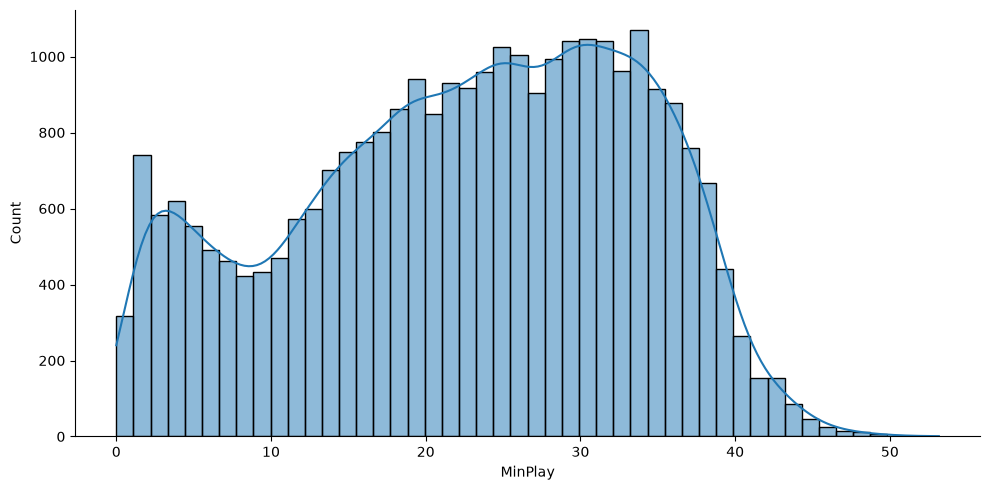

In [23]:
sns.displot(data = new_df, x = 'MinPlay', kind = 'hist', kde = True, aspect = 2)
plt.show()

<span style="color:#E2725B">

Interestingly, We have a bimodal distribution here, where we have some values peaking around the 4 to 5 mark and many of the values really concentrated around the 18-ish to 35 window or range. The reason this is interesting is because if minutes played was heavily correlated to points scored, then we would have identical distributions here between the two graphs, and that's not the case, so we'll investigate this. 

</span>

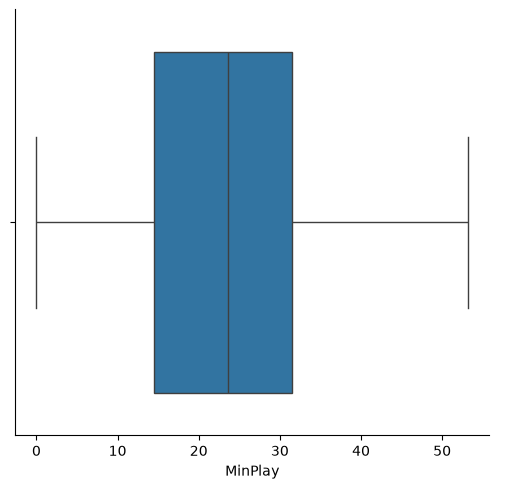

In [24]:
sns.catplot(data = new_df, x = 'MinPlay', kind = 'box')
plt.show()

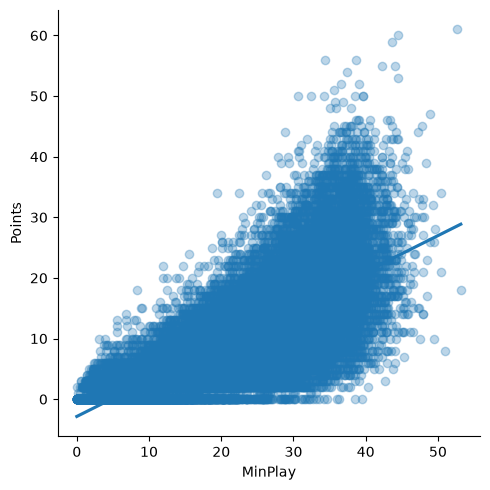

In [25]:
sns.lmplot(data = new_df, x = 'MinPlay', y = 'Points', scatter_kws={'alpha': 0.3})
plt.show()

<span style="color:#E2725B">

Since there is a large sample size (over 28,000), this scatterplot is very hard to read but there are some ideas we're getting here:

There is a positive correlation between minutes played and points scored. Makes sense. The more time you have on the court, the more chances you have for buckets.
There are some outliers here which we affirmed above, looking at the upper end of the data for minutes and points.

</span>

<span style="color:#17A697">

#### 1D. Basic summary statistics

</span>

In [26]:
new_df[['Points', 'MinPlay']].describe()

,Points,MinPlay
count,28265.000000,28265.000000
mean,10.606828,22.556967
std,8.844302,10.999814
min,0.000000,0.000000
25%,4.000000,14.533333
50%,9.000000,23.666667
75%,16.000000,31.450000
max,61.000000,53.166667


<span style="color:#E2725B">

The ranges here are very similar, so no need to standardize.

</span>

<span style="color:#17A697">

#### 1E. Look for outliers and anomalies

</span>

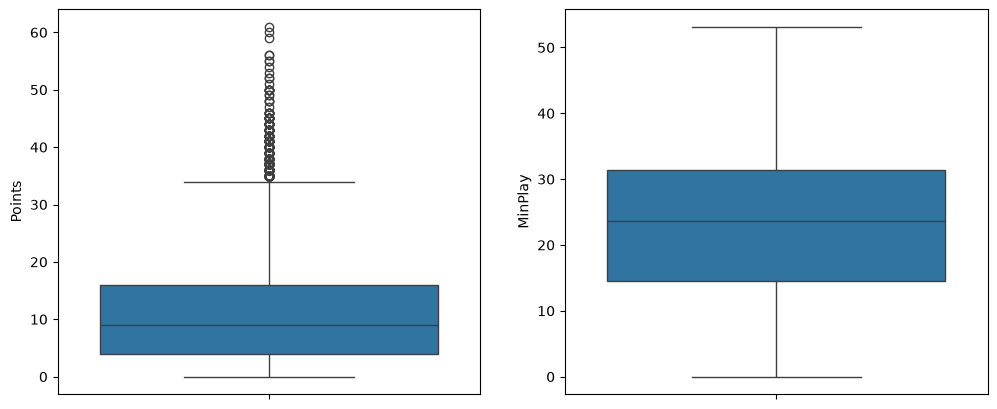

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data = new_df, y = 'Points', ax = axes[0])
sns.boxplot(data = new_df, y = 'MinPlay', ax = axes[1])
plt.show()

<span style="color:#E2725B">

Points has a ton of outliers. This is consistent with the histogram which was heavily skewed, as opposed to minutes played, which had something a lot closer to a normal distribution, though bimodal. 

Points (first box):
- Box shows IQR (25th-75th percentile): roughly 4-31 pts
- Median (middle line): ~9 pts
- Many outliers above the whisker (around 34-62 pts)—high scorers

MinPlay (second box):
- Box: roughly 14-31 minutes
- Median: ~24 min
- Few outliers on either end
- Much more symmetric than Points

</span>

In [28]:
q1_points = new_df['Points'].quantile(0.25)
q3_points = new_df['Points'].quantile(0.75)
iqr_points = q3_points - q1_points
lower_bound_points = q1_points - 1.5 * iqr_points
upper_bound_points = q3_points + 1.5 * iqr_points
outliers_points = pd.DataFrame(new_df[(new_df['Points'] < lower_bound_points) | (new_df['Points'] > upper_bound_points)])
outliers_points[['Player', 'Team', 'Points', 'MinPlay']].head(10)

,Player,Team,Points,MinPlay
0,Jayson Tatum,BOS,37,30.300000
1,Anthony Davis,LAL,36,37.583333
43,Lauri Markkanen,UTA,35,34.566667
48,Cam Thomas,BRK,36,33.716667
376,Trae Young,ATL,38,41.466667
377,Coby White,CHI,35,34.366667
378,Anthony Davis,LAL,35,37.500000
379,Giannis Antetokounmpo,MIL,38,35.133333
607,Nikola Jokić,DEN,41,36.766667
609,Luka Dončić,DAL,40,39.400000


In [29]:
outliers_points[['Player', 'Team', 'Points', 'MinPlay']].nunique()

Player      90
Team        30
Points      25
MinPlay    333
dtype: int64

<span style="color:#E2725B">

'Points' has these many outliers for these 4 variables.

</span>

In [30]:
q1_minplay = new_df['MinPlay'].quantile(0.25)
q3_minplay = new_df['MinPlay'].quantile(0.75)
iqr_minplay = q3_minplay - q1_minplay 
lower_bound_minplay = q1_minplay - 1.5 * iqr_minplay
upper_bound_minplay = q3_minplay + 1.5 * iqr_minplay
outliers_minplay = pd.DataFrame(new_df[(new_df['MinPlay'] < lower_bound_minplay) | (new_df['MinPlay'] > upper_bound_minplay)])
outliers_minplay[['Player', 'Team', 'Points', 'MinPlay']].head(10)

,Player,Team,Points,MinPlay


<span style="color:#E2725B">

There are no outliers for minutes played, which is very different from points. 

</span>

<span style="color:#17A697">

## 2. Data Preparation

- Handle missing values
- Remove or flag problematic rows
- Ensure variables are in correct format for modeling

</span>

In [31]:
new_df[['Points', 'MinPlay']].nunique()

Points       60
MinPlay    2700
dtype: int64

<span style="color:#E2725B">

There are 60 unique values for Points and 2700 unique values for minutes played.

</span>

In [32]:
new_df[['Points', 'MinPlay']].isna().sum()

Points     0
MinPlay    0
dtype: int64

<span style="color:#E2725B">

No missing values. Hooray!

</span>

In [33]:
new_df.query('Points == 0 and MinPlay == 0')

,Player,Team,Opp,Result,MinPlay,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,Points,GameScore,Date
5157,Anthony Gill,WAS,BOS,L,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2024-11-22
5443,Alex Len,SAC,BRK,L,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2024-11-24
8075,Trendon Watford,BRK,MEM,L,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2024-12-13
15833,Joe Ingles,MIN,SAC,L,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2025-02-03
18576,Steven Adams,HOU,MIL,W,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2025-02-25
19907,Skal Labissière,SAC,DEN,L,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2025-03-05
20864,Tony Bradley,IND,MIL,W,0.0,0,0,NaN,0,0,...,1,1,0,0,0,0,0,0,0.3,2025-03-11
22816,Drew Eubanks,LAC,OKC,L,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2025-03-23
24244,Luka Garza,MIN,DEN,W,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2025-04-01
27208,Thomas Bryant,IND,MIL,W,0.0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0.0,2025-04-29


<span style="color:#E2725B">

Checking to see if taking out the athletes who played no minutes and therefor scored no points. Since there are only 10 of over 28,000 rows which have 0 points and 0 minutes played, this subset of data ends up being inconsequential. We're going to leave it in the data frame. No need to remove. 

</span>

<span style="color:#17A697">

## 3. Linear Regression: Points from Minutes Played

- Fit OLS model: `PTS ~ MP`
- Extract and interpret coefficients
- Examine model summary (R-squared, F-statistic, p-values)

</span>

In [35]:
model = smf.ols('Points ~ MinPlay', data = new_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Points   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                 3.460e+04
Date:                Wed, 26 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:12:47   Log-Likelihood:                -90420.
No. Observations:               28265   AIC:                         1.808e+05
Df Residuals:                   28263   BIC:                         1.809e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8486      0.080    -35.395      0.000      -3.006      -2.691
MinPlay        0.5965      0.003    186.009      0.000       0.590       0.603
==============================================================================
Omnibus:                     3023.031   Durbin-Watson:                   1.189
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6301.480
Skew:                           0.681   Prob(JB):                         0.00
Kurtosis:                       4.870   Cond. No.                         57.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:#E2725B">

Some important figures here:

- R-squared / 0.550
- Prob (F-statistic) / 0.00
- Intercept / coef -2.8486 with p-value 0.000
- MinPlay / 0.5965 with p-value 0.000

The R² of 0.550 means minutes played explains about 55% of the variance in points—decent but not great. There's still a lot of unexplained variation (45%), which makes sense: some players are efficient scorers, others aren't, regardless of minutes.

The F-statistic of 3.460e+04 with Prob(F-stat) = 0.00 says the model is highly significant overall—minutes does meaningfully predict points, even if imperfectly.

The MinPlay coefficient of 0.5965 means each additional minute adds ~0.6 points on average. That's interpretable and significant (p=0.000).

</span>

<span style="color:#17A697">

## 4. Model Diagnostics & Assumptions

- Check normality of residuals (Jarque-Bera test, Q-Q plot)
- Examine residual plots
- Assess homoscedasticity
- Identify any violations of assumptions

</span>

In [36]:
residuals = model.resid
print(residuals)

0        21.774385
1        16.429813
2        10.961584
3         2.645141
4         9.428849
           ...    
28260    -6.824783
28261     2.212325
28262    -4.428806
28263     2.530463
28264    -9.409655
Length: 28265, dtype: float64


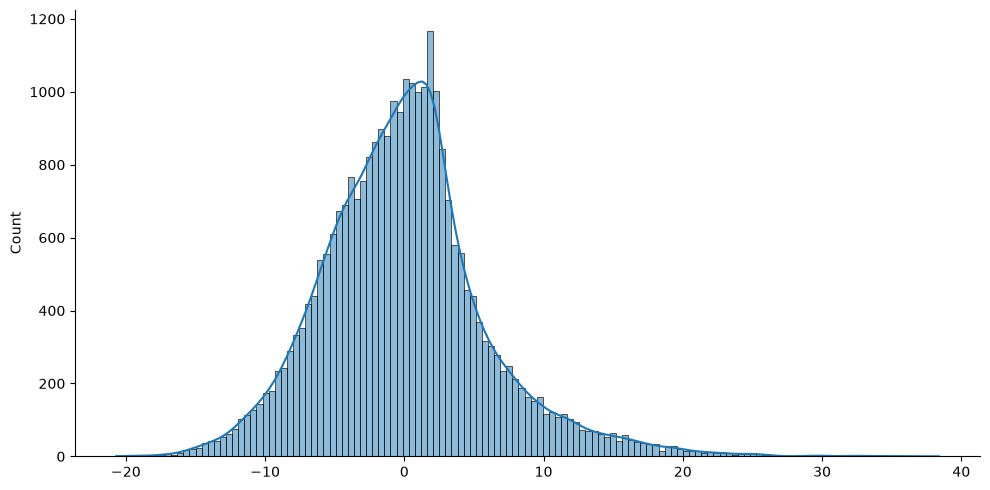

In [37]:
sns.displot(residuals, kind = 'hist', kde = True, aspect = 2)
plt.show()

<span style="color:#E2725B">

The histogram shows a roughly bell-curve shape, centered around 0, with the KDE curve following it closely. But the Jarque-Bera test shows Prob(JB) = 0.00—which means residuals are NOT normal. The threshold is 0.05; anything below is NOT normal.

</span>

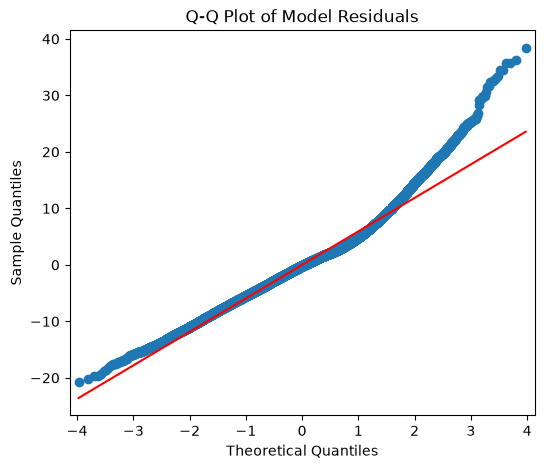

In [38]:
fig, ax = plt.subplots(figsize = (6,5))
qqplot(model.resid, line = 's', ax = ax)
ax.set_title('Q-Q Plot of Model Residuals')
plt.show()

<span style="color:#E2725B">

The Jarque-Bera test detected non-normality, and the Q-Q plot confirms that. What we see in this dataset of over 28,000 observations is mostly an alignment here, but there is some deviation, which shows where the distribution is happening for residuals. The model is **mostly** valid.

</span>

In [39]:
fitted_values = model.fittedvalues
print(fitted_values)

0        15.225615
1        19.570187
2        13.038416
3        15.354859
4        12.571151
           ...    
28260     6.824783
28261    -2.212325
28262     4.428806
28263    -2.530463
28264     9.409655
Length: 28265, dtype: float64


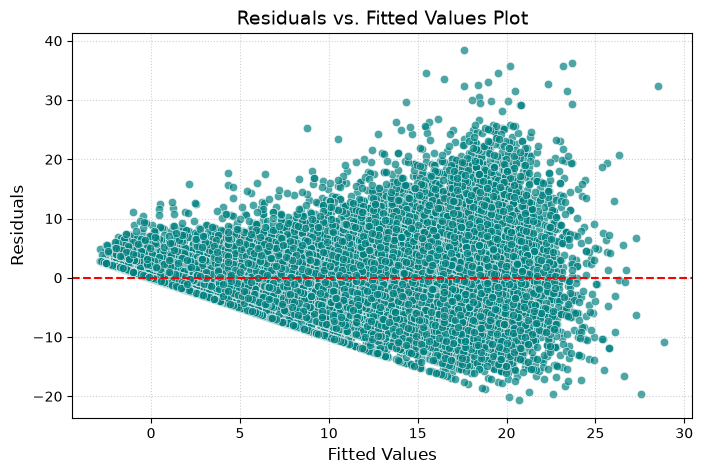

In [40]:
plt.figure(figsize = (8,5))
sns.scatterplot(x = model.fittedvalues, y = model.resid, alpha = 0.7, color = 'teal')
plt.axhline(y = 0, color = 'red', linestyle = '--', linewidth = 1.5)

plt.title('Residuals vs. Fitted Values Plot', fontsize = 14)
plt.xlabel('Fitted Values', fontsize = 12)
plt.ylabel('Residuals', fontsize = 12)
plt.grid(True, linestyle = ':', alpha = 0.6)

plt.show()


<span style="color:#E2725B">

Here's the rundown of where we are so far:

- R² = 0.55: Model explains half the variance. Minutes alone isn't enough—other factors drive scoring.
- Q-Q plot deviation: Residuals aren't normally distributed, especially in the tails. The JB test picked this up statistically.
- Funnel shape: Heteroscedasticity. Errors grow at extreme fitted values. The model's predictions get less reliable the further you move from the center.

Together, these say: Linear regression fits the data, but it's making assumptions that don't hold perfectly. The model isn't "wrong"—it's just limited. For this dataset, a linear model captures the general trend (minutes → points), but it's missing structure.

The funnel makes sense: minutes played is a necessary condition for scoring, but it's not sufficient:
- High-minute players have more variability in how they score
- Low-minute players are more constrained.

This points to what's missing: player-level factors. Efficiency (FG%), role (starter vs. bench), position, quality of teammates—those would explain why two players with the same minutes can have wildly different points.

The model found the floor (minutes matters), but it's missing the ceiling (quality matters).

</span>

<span style="color:#17A697">

## 5. Inference & Interpretation

- Confidence intervals on coefficient estimates
- P-values and statistical significance
- Practical interpretation of results

</span>

In [41]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Points   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                 3.460e+04
Date:                Wed, 26 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:12:47   Log-Likelihood:                -90420.
No. Observations:               28265   AIC:                         1.808e+05
Df Residuals:                   28263   BIC:                         1.809e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8486      0.080    -35.395      0.000      -3.006      -2.691
MinPlay        0.5965      0.003    186.009      0.000       0.590       0.603
==============================================================================
Omnibus:                     3023.031   Durbin-Watson:                   1.189
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6301.480
Skew:                           0.681   Prob(JB):                         0.00
Kurtosis:                       4.870   Cond. No.                         57.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:#E2725B">

Bringing this all together a little more:

- P-value is 0.000, so statistically significant. The relationship between minutes played and points scored is a real one that is not reliant on randomness. 
- CI = [0.590, 0.603]. We're 95% confident that the slope lies between these two figures. For every additional minute played, a player scores about half a point more (just the average). Not all players score at the same rate per minute. Star players and bench players playing for the same number of minutes will have different results. 

However, in the diagnostics, what we found is that we're not invalidating the slope, but that the confidence intervals and the p-values are a little less trustworthy than reported. The true uncertainty is probably a little bit wider because variance isn't constant. 

</span>

<span style="color:#17A697">

## 6. Predictions & Visualization

- Generate predictions across a range of MP values
- Calculate confidence intervals and prediction intervals
- Create visualization grid showing:
    - Predicted line (regression line)
    - Confidence interval ribbon
    - Uncertainty bands


</span>

In [43]:
new_df.columns

Index(['Player', 'Team', 'Opp', 'Result', 'MinPlay', 'FG', 'FGA', 'FG%', '3P',
       '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'Points', 'GameScore', 'Date'],
      dtype='str')

In [48]:
mp_range = np.linspace(new_df['MinPlay'].min(), new_df['MinPlay'].max(), 101)
pred_df = pd.DataFrame({'MinPlay': mp_range})

<span style="color:#E2725B">

Generating a range of values for MinPlay.

</span>

In [50]:
pred_df.shape

(101, 1)

In [51]:
pred_df.head(10)

,MinPlay
0,0.000000
1,0.531667
2,1.063333
3,1.595000
4,2.126667
5,2.658333
6,3.190000
7,3.721667
8,4.253333
9,4.785000


In [58]:
predictions = model.get_prediction(pred_df)
pred_df['predicted'] = predictions.predicted_mean
pred_df['ci_lower'] = predictions.conf_int()[:, 0]
pred_df['ci_upper'] = predictions.conf_int()[:, 1]

<span style="color:#E2725B">

Calculating confidence and prediction values.

</span>

In [69]:
print(dir(predictions))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'conf_int', 'df', 'dist', 'dist_args', 'predicted', 'predicted_mean', 'row_labels', 'se', 'se_mean', 'se_obs', 'summary_frame', 'var_pred', 'var_pred_mean', 'var_resid']


In [71]:
summary = predictions.summary_frame()
pred_df['obs_ci_lower'] = summary['obs_ci_lower']
pred_df['obs_ci_upper'] = summary['obs_ci_upper']

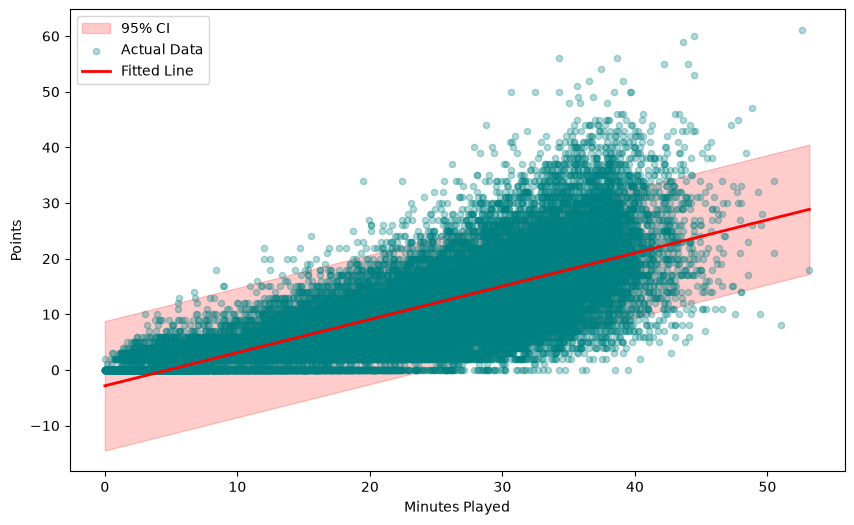

In [72]:
plt.figure(figsize = (10, 6))

# CI ribbon
plt.fill_between(
    x = pred_df['MinPlay'],
    y1 = pred_df['obs_ci_lower'],
    y2 = pred_df['obs_ci_upper'],
    color = 'red',
    alpha = 0.2,
    label = '95% CI'
)

# Scatter of actual data
plt.scatter(new_df['MinPlay'], new_df['Points'], alpha = 0.3, s = 20, color = 'teal', label = 'Actual Data')

# Line of predictions
plt.plot(pred_df['MinPlay'], pred_df['predicted'], color = 'red', linewidth = 2, label = 'Fitted Line')

plt.xlabel('Minutes Played')
plt.ylabel('Points')
plt.legend()
plt.show()


<span style="color:#17A697">

## 7. Repeat for Additional Outcomes (Optional)

- Build separate models for: FG, 3P, FT, AST from MP
- Apply same workflow to each

</span>

<span style="color:#17A697">

## 8. Summary & Conclusions

- Compare model results across all outcomes
- Discuss findings and patterns

</span>

***

## Formatting Styles


<span style="color:#17A697">

### Section

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>



<span style="color:#E2725B">

#### Subsection

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>

